Running simulation: 10 iterations, 100 patches each.

Coverage counting completed.


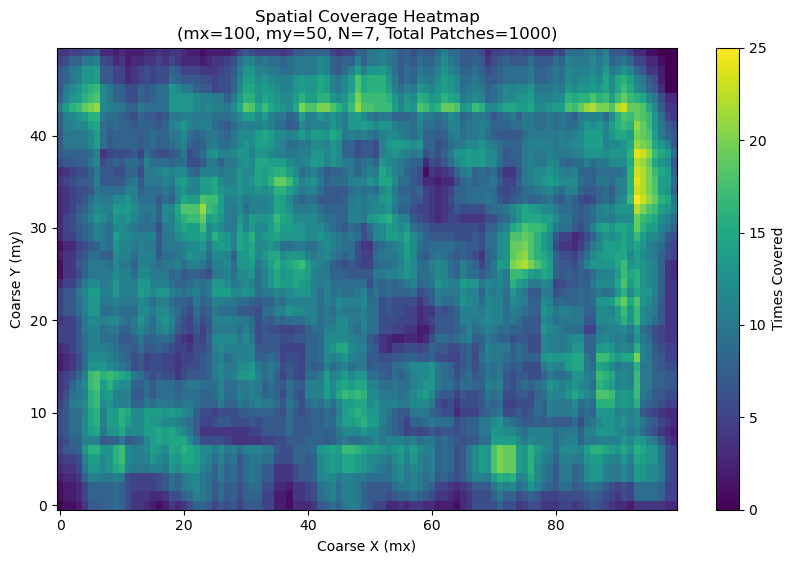

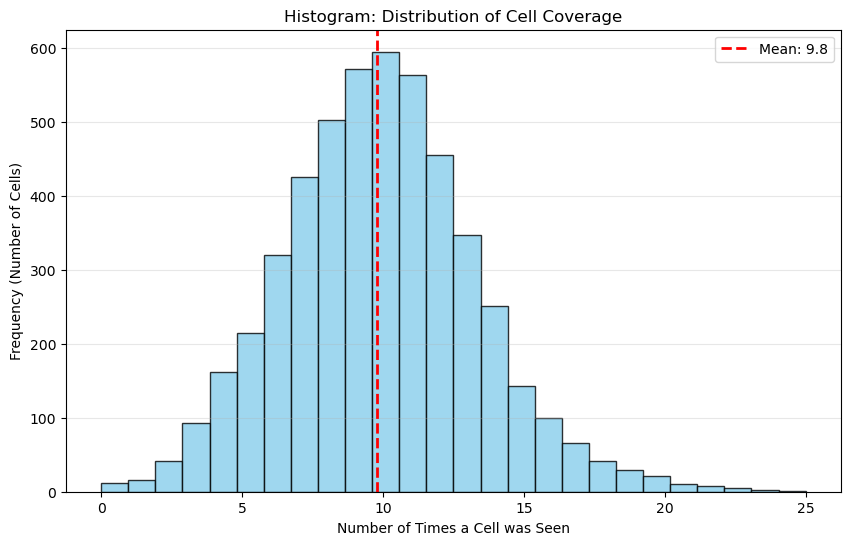

------------------------------
Coverage Stats for 100x50 grid:
  Min times seen: 0
  Max times seen: 25
  Average (Mean): 9.80
  Total cells covered: 4988 / 5000 (99.8%)
------------------------------


In [12]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# ------------------------------------------------------------------
# Track and plot coverage with Clamping Logic and Histogram
# ------------------------------------------------------------------
def track_and_plot_coarse_coverage(
    mx, my, N, num_iterations=50, patches_per_iter=200
):
    """
    Counts how many times each cell (mx, my) is covered using Clamped Padding logic.
    Plots both a spatial heatmap and a histogram of the coverage counts.
    """
    coverage_map = torch.zeros(mx, my, dtype=torch.float32)
    
    for it in range(num_iterations):
        # Improved Sampling: Clamped Padding Logic
        x_starts = torch.randint(-(N // 2), mx - (N // 2), (patches_per_iter,))
        y_starts = torch.randint(-(N // 2), my - (N // 2), (patches_per_iter,))
        
        x_starts = torch.clamp(x_starts, 0, mx - N)
        y_starts = torch.clamp(y_starts, 0, my - N)
        
        for x_start, y_start in zip(x_starts, y_starts):
            xs, ys = x_start.item(), y_start.item()
            # Mark the N x N block in the coverage map
            coverage_map[xs : xs + N, ys : ys + N] += 1

    print("\nCoverage counting completed.")
    
    # --- PLOT 1: SPATIAL HEATMAP ---
    plt.figure(figsize=(10, 6))
    plt.imshow(coverage_map.numpy().T, cmap='viridis', origin='lower', aspect='auto')
    plt.colorbar(label='Times Covered')
    plt.title(f"Spatial Coverage Heatmap\n(mx={mx}, my={my}, N={N}, Total Patches={num_iterations * patches_per_iter})")
    plt.xlabel("Coarse X (mx)")
    plt.ylabel("Coarse Y (my)")
    plt.show()
    
    # --- PLOT 2: COVERAGE HISTOGRAM ---
    coverage_flat = coverage_map.flatten().numpy()
    
    plt.figure(figsize=(10, 6))
    plt.hist(coverage_flat, bins=int(coverage_flat.max() - coverage_flat.min() + 1), 
             color='skyblue', edgecolor='black', alpha=0.8)
    
    # Vertical line for the mean coverage
    plt.axvline(coverage_flat.mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {coverage_flat.mean():.1f}')
    
    plt.title("Histogram: Distribution of Cell Coverage")
    plt.xlabel("Number of Times a Cell was Seen")
    plt.ylabel("Frequency (Number of Cells)")
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.show()
    
    # Stats Summary
    print("-" * 30)
    print(f"Coverage Stats for {mx}x{my} grid:")
    print(f"  Min times seen: {coverage_map.min().item():.0f}")
    print(f"  Max times seen: {coverage_map.max().item():.0f}")
    print(f"  Average (Mean): {coverage_flat.mean():.2f}")
    print(f"  Total cells covered: {(coverage_map > 0).sum().item()} / {mx * my} ({(coverage_map > 0).float().mean()*100:.1f}%)")
    print("-" * 30)
    
    return coverage_map

if __name__ == "__main__":
    # Parameters
    mx, my = 100, 50          
    N = 7                     
    num_iterations = 10       
    patches_per_iter = 100    

    print(f"Running simulation: {num_iterations} iterations, {patches_per_iter} patches each.")
    coverage_map = track_and_plot_coarse_coverage(mx, my, N, num_iterations, patches_per_iter)

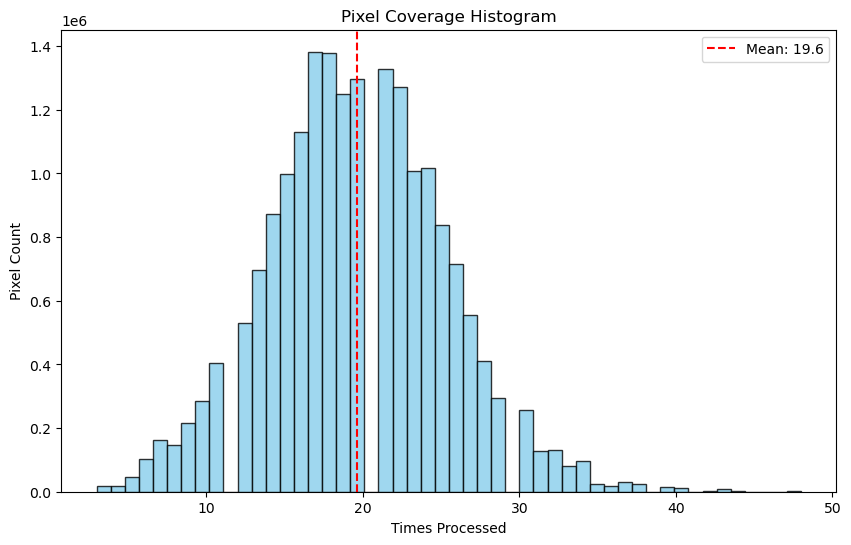

In [46]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------------
# Dummy magnifier
# ------------------------------------------------------------------
def dummy_magnifier(patch_input):
    out = patch_input[:, 0:1, :, :, :] + torch.randn_like(patch_input[:, 0:1, :, :, :]) * 0.03
    return out

# ------------------------------------------------------------------
# Prepare patch input
# ------------------------------------------------------------------
def prepare_patch_input(coarse_u, fine_bed, i_start, j_start, N, f, device):
    nb, nt = coarse_u.shape[0], coarse_u.shape[-1]
    P_fine = N * f

    coarse_patch = coarse_u[:, i_start:i_start+N, j_start:j_start+N, :]
    coarse_patch = coarse_patch.permute(0, 3, 1, 2)
    interp_u = F.interpolate(coarse_patch, scale_factor=(float(f), float(f)), mode='bilinear', align_corners=False)
    interp_u = interp_u.permute(0, 2, 3, 1)

    i_f = i_start * f
    j_f = j_start * f
    
    # Slice the fine bed
    bed_patch = fine_bed[:, i_f:i_f + P_fine, j_f:j_f + P_fine]
    bed_patch = bed_patch.unsqueeze(-1).expand(-1, -1, -1, nt)

    # Cat along dimension 1 (channel/input type dimension)
    patch_input = torch.cat([interp_u.unsqueeze(1), bed_patch.unsqueeze(1)], dim=1)
    return patch_input.to(device)

# ------------------------------------------------------------------
# Inference loop using Clamped Padding Logic
# ------------------------------------------------------------------
def run_full_domain_inference_pure_random(
    coarse_u, fine_bed, N=7, f=8, num_iterations=10, patches_per_iter=100, device='cuda'
):
    nb, mx, my, nt = coarse_u.shape
    nx, ny = fine_bed.shape[1], fine_bed.shape[2]
    P_fine = N * f

    accumulated = torch.zeros(nb, nx, ny, nt, device=device)
    weight_map = torch.zeros(nb, nx, ny, nt, device=device)

    for it in range(num_iterations):
        print(f"  Iteration {it+1}/{num_iterations}", end='\r')

        # Clamped Padding Logic
        x_starts = torch.randint(-(N // 2), mx - (N // 2), (patches_per_iter,), device=device)
        y_starts = torch.randint(-(N // 2), my - (N // 2), (patches_per_iter,), device=device)
        
        x_starts = torch.clamp(x_starts, 0, mx - N)
        y_starts = torch.clamp(y_starts, 0, my - N)

        for idx in range(patches_per_iter):
            i = x_starts[idx].item()
            j = y_starts[idx].item()

            patch_input = prepare_patch_input(coarse_u, fine_bed, i, j, N, f, device)
            patch_output = dummy_magnifier(patch_input)

            i_fine, j_fine = i * f, j * f
            accumulated[:, i_fine:i_fine+P_fine, j_fine:j_fine+P_fine, :] += patch_output.squeeze(1)
            weight_map[:, i_fine:i_fine+P_fine, j_fine:j_fine+P_fine, :] += 1

    high_res_u = accumulated / weight_map.clamp(min=1e-6)
    return high_res_u, weight_map


def run_full_domain_inference_parallel(
    coarse_u, fine_bed, N=7, f=8, num_iterations=10, patches_per_iter=100, device='cuda'
):
    nb, mx, my, nt = coarse_u.shape
    nx, ny = fine_bed.shape[1], fine_bed.shape[2]
    P_fine = N * f

    accumulated = torch.zeros(nb, nx, ny, nt, device=device)
    weight_map = torch.zeros(nb, nx, ny, nt, device=device)

    for it in range(num_iterations):
        print(f"  Iteration {it+1}/{num_iterations}", end='\r')

        # 1. Generate all starts at once (Clamped Padding Logic)
        x_starts = torch.randint(-(N // 2), mx - (N // 2), (patches_per_iter,), device=device)
        y_starts = torch.randint(-(N // 2), my - (N // 2), (patches_per_iter,), device=device)
        x_starts = torch.clamp(x_starts, 0, mx - N)
        y_starts = torch.clamp(y_starts, 0, my - N)

        # 2. Batch Patch Extraction
        # We prepare a list of patch inputs to stack them into one big batch
        # Note: If your GPU memory is limited, you can split patches_per_iter 
        # into smaller sub-batches (e.g., 32 at a time).
        patch_list = []
        for idx in range(patches_per_iter):
            i, j = x_starts[idx].item(), y_starts[idx].item()
            # prepare_patch_input returns [nb, 2, P_fine, P_fine, nt]
            patch_list.append(prepare_patch_input(coarse_u, fine_bed, i, j, N, f, device))
        
        # Combined batch: [patches_per_iter * nb, 2, P_fine, P_fine, nt]
        batch_input = torch.cat(patch_list, dim=0)

        # 3. Parallel Magnifier Execution
        # Process all patches at once on the GPU
        batch_output = dummy_magnifier(batch_input) # Output: [TotalBatch, 1, P_fine, P_fine, nt]
        batch_output = batch_output.squeeze(1) # [TotalBatch, P_fine, P_fine, nt]

        # 4. Optimized Accumulation
        # We still loop to place them back, but the "heavy lifting" (the model) was parallel
        for idx in range(patches_per_iter):
            i, j = x_starts[idx].item(), y_starts[idx].item()
            i_f, j_f = i * f, j * f
            
            # Extract the specific output for this patch from the batch
            # batch_output indices: [patch_idx * nb : (patch_idx + 1) * nb]
            accumulated[:, i_f:i_f+P_fine, j_f:j_f+P_fine, :] += batch_output[idx*nb : (idx+1)*nb]
            weight_map[:, i_f:i_f+P_fine, j_f:j_f+P_fine, :] += 1

    high_res_u = accumulated / weight_map.clamp(min=1e-6)
    return high_res_u, weight_map

def plot_coverage_histogram(weight_map):
    coverage = weight_map.squeeze(0).cpu().numpy().flatten()
    coverage = coverage[coverage > 0] 

    plt.figure(figsize=(10, 6))
    plt.hist(coverage, bins=50, color='skyblue', edgecolor='black', alpha=0.8)
    plt.axvline(np.mean(coverage), color='red', linestyle='dashed', label=f'Mean: {np.mean(coverage):.1f}')
    plt.title("Pixel Coverage Histogram")
    plt.xlabel("Times Processed")
    plt.ylabel("Pixel Count")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # CORRECTED PARAMETERS: nx = mx * f, ny = my * f
    nb, mx, my, nt, f = 4, 100, 50, 15, 8
    nx, ny = mx * f, my * f  # 800, 400
    N = 7
             
    coarse_u = torch.randn(nb, mx, my, nt, device=device)
    fine_bed = torch.randn(nb, nx, ny, device=device)

    high_res_u, weight_map = run_full_domain_inference_pure_random(
        coarse_u, fine_bed, N=N, f=f, num_iterations=20, patches_per_iter=100, device=device
    )

    plot_coverage_histogram(weight_map)

In [47]:
weight_map1.mean(), weight_map1.min(), weight_map1.max()

(tensor(19.6000, device='cuda:0'),
 tensor(3., device='cuda:0'),
 tensor(52., device='cuda:0'))

In [45]:
weight_map2.mean(), weight_map2.min(), weight_map2.max()

(tensor(19.6000, device='cuda:0'),
 tensor(2., device='cuda:0'),
 tensor(54., device='cuda:0'))